In [11]:
import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid

# Porosity values to simulate
porosity_values = [round(p, 2) for p in np.arange(0.30, 0.71, 0.01)]
all_data = []

for eps in porosity_values:
    print(f"Simulating porosity = {eps}")
    model = pybamm.lithium_ion.DFN()
    param = model.default_parameter_values.copy()
    param.update({"Negative electrode porosity": eps})
    
    experiment = pybamm.Experiment(["Discharge at 1C until 2.5V"])
    sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
    solution = sim.solve()

    t = solution["Time [s]"].entries
    v = solution["Terminal voltage [V]"].entries
    neg_eta = solution["X-averaged negative electrode reaction overpotential [V]"].entries
    elyte_eta = solution["X-averaged electrolyte overpotential [V]"].entries
    neg_ohmic = solution["X-averaged negative electrode ohmic losses [V]"].entries
    neg_conc = solution["X-averaged negative particle concentration [mol.m-3]"](t)
    neg_conc = np.mean(neg_conc, axis=0)
    neg_ocp = solution["X-averaged negative electrode open-circuit potential [V]"].entries
    elyte_ohmic = solution["X-averaged electrolyte ohmic losses [V]"].entries


    # Interpolate to uniform time grid
    t_interp = np.linspace(0, t[-1], 500)
    data = {
        "Ohmic negative electrode overpotential": np.interp(t_interp, t, neg_ohmic),
        "Electrolyte concentration overpotential": np.interp(t_interp, t, elyte_eta),
        "Negative reaction overpotential": np.interp(t_interp, t, neg_eta),
        "voltage": np.interp(t_interp, t, v),
        "Negative particle concentration overpotential": np.interp(t_interp, t, neg_conc),
        "Negative open-circuit potential": np.interp(t_interp, t, neg_ocp),
        "Ohmic electrolyte overpotential": np.interp(t_interp, t, elyte_ohmic),
        "porosity": eps
    }
    
    df = pd.DataFrame(data)
    all_data.append(df)

# Combine and save
final_df = pd.concat(all_data, ignore_index=True)
final_df.to_csv("battery_data_selected_features3.csv", index=False)

Simulating porosity = 0.3
Simulating porosity = 0.31
Simulating porosity = 0.32
Simulating porosity = 0.33
Simulating porosity = 0.34
Simulating porosity = 0.35
Simulating porosity = 0.36
Simulating porosity = 0.37
Simulating porosity = 0.38
Simulating porosity = 0.39
Simulating porosity = 0.4
Simulating porosity = 0.41
Simulating porosity = 0.42
Simulating porosity = 0.43
Simulating porosity = 0.44
Simulating porosity = 0.45
Simulating porosity = 0.46
Simulating porosity = 0.47
Simulating porosity = 0.48
Simulating porosity = 0.49
Simulating porosity = 0.5
Simulating porosity = 0.51
Simulating porosity = 0.52
Simulating porosity = 0.53
Simulating porosity = 0.54
Simulating porosity = 0.55
Simulating porosity = 0.56
Simulating porosity = 0.57
Simulating porosity = 0.58
Simulating porosity = 0.59
Simulating porosity = 0.6
Simulating porosity = 0.61
Simulating porosity = 0.62
Simulating porosity = 0.63
Simulating porosity = 0.64
Simulating porosity = 0.65
Simulating porosity = 0.66
Simul

In [13]:
final_df

,Ohmic negative electrode overpotential,Electrolyte concentration overpotential,Negative reaction overpotential,voltage,Negative particle concentration overpotential,Negative open-circuit potential,Ohmic electrolyte overpotential,porosity
0,0.000015,-0.008248,0.005407,3.771713,19986.609595,0.175189,-0.008248,0.3
1,0.000015,-0.008930,0.005349,3.769048,19970.071621,0.175330,-0.008221,0.3
2,0.000015,-0.009613,0.005291,3.766382,19953.533646,0.175471,-0.008193,0.3
3,0.000015,-0.010295,0.005233,3.763716,19936.995671,0.175612,-0.008166,0.3
4,0.000015,-0.010977,0.005174,3.761050,19920.457697,0.175753,-0.008138,0.3
...,...,...,...,...,...,...,...,...
20495,0.000048,-0.011085,0.005786,2.703536,5126.635898,0.267487,-0.006179,0.7
20496,0.000048,-0.011068,0.005804,2.652846,5095.725303,0.268273,-0.006170,0.7
20497,0.000048,-0.011051,0.005823,2.602156,5064.814708,0.269059,-0.006162,0.7
20498,0.000048,-0.011034,0.005841,2.551465,5033.904114,0.269845,-0.006153,0.7


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("battery_data_selected_features3.csv")

# Features to use 
feature_cols = ["Ohmic negative electrode overpotential", "Electrolyte concentration overpotential", "Negative reaction overpotential", "voltage", "Negative particle concentration overpotential", "Negative open-circuit potential", "Ohmic electrolyte overpotential"]
target_col = "porosity"

# Convert to numpy arrays
X_data = df[feature_cols].values
y_data = df[[target_col]].values

# Normalize features and targets
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

# Windowing parameters
window_size = 20
stride = 1
samples_per_porosity = 500
total_samples = len(X_scaled)

X_seq = []
y_seq = []

# Loop through each porosity block (500 rows per block)
for start in range(0, total_samples, samples_per_porosity):
    X_block = X_scaled[start:start + samples_per_porosity]
    y_block_value = y_scaled[start]  # Same porosity value for this block

    for i in range(0, samples_per_porosity - window_size, stride):
        X_seq.append(X_block[i:i + window_size])
        y_seq.append(y_block_value)

# Convert to arrays
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f"Created {X_seq.shape[0]} sequences of shape {X_seq.shape[1:]}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=True, random_state=42)

print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")


Created 19680 sequences of shape (20, 7)
Training samples: 15744 | Test samples: 3936


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SimpleRNN model
model_rnn = Sequential([
    SimpleRNN(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_rnn.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0477 - mae: 0.1494 - val_loss: 0.0037 - val_mae: 0.0508
Epoch 2/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0048 - mae: 0.0549 - val_loss: 0.0016 - val_mae: 0.0343
Epoch 3/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - mae: 0.0473 - val_loss: 0.0021 - val_mae: 0.0389
Epoch 4/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0026 - mae: 0.0407 - val_loss: 9.1585e-04 - val_mae: 0.0232
Epoch 5/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0021 - mae: 0.0360 - val_loss: 3.5475e-04 - val_mae: 0.0154
Epoch 6/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - mae: 0.0336 - val_loss: 6.1228e-04 - val_mae: 0.0200
Epoch 7/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0016 - mae: 0.0314 - val_loss: 3.7215e-04 - val_mae: 0.0152
Epoch 8/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014 - mae: 0.0292 - val_loss: 4.4502e-04 - val_mae: 0.0171
Epoch 9/100
492/492 ━━━━━━━━

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
RMSE: 0.0052
MAE:  0.0042
R²:   0.9980


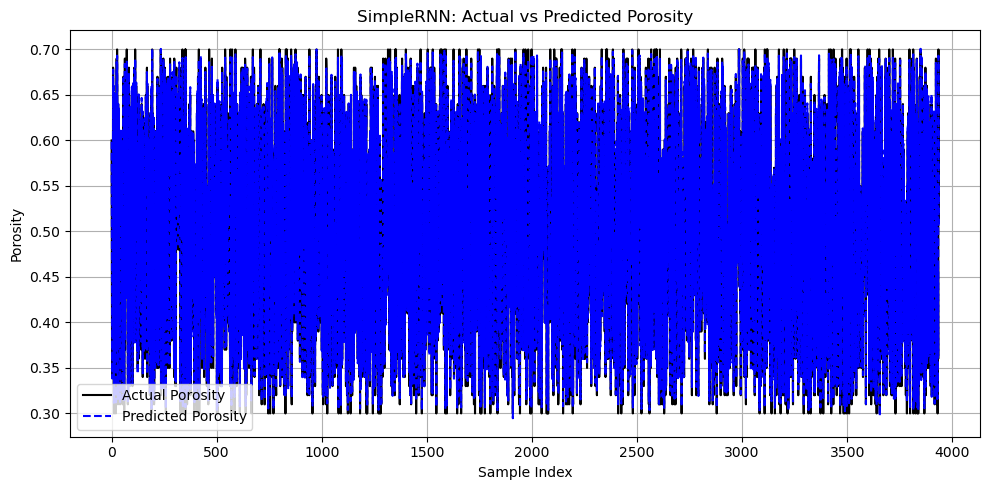

y_true[:5]: [0.6  0.49 0.35 0.34 0.37]
y_pred[:5]: [0.59857816 0.49460182 0.35984775 0.33832586 0.36433583]


In [18]:

y_pred_scaled = model_rnn.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("SimpleRNN: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


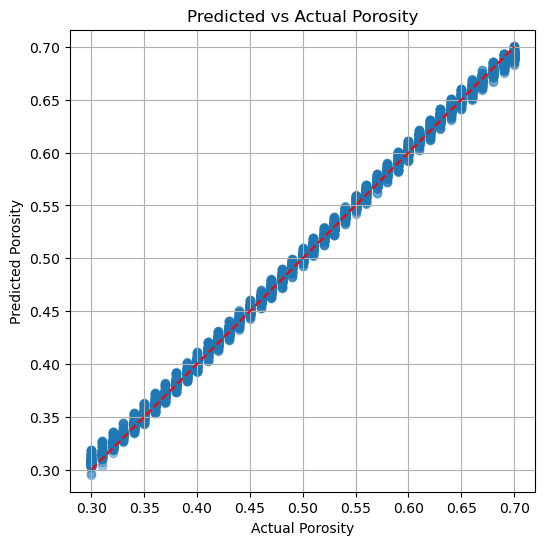

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()


In [20]:
from tensorflow.keras.layers import LSTM

# Build LSTM model
model_lstm = Sequential([
    LSTM(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_lstm.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0155 - mae: 0.0806 - val_loss: 0.0020 - val_mae: 0.0365
Epoch 2/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0018 - mae: 0.0334 - val_loss: 0.0027 - val_mae: 0.0447
Epoch 3/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0010 - mae: 0.0254 - val_loss: 0.0016 - val_mae: 0.0319
Epoch 4/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.9625e-04 - mae: 0.0207 - val_loss: 0.0027 - val_mae: 0.0409
Epoch 5/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.5495e-04 - mae: 0.0186 - val_loss: 0.0034 - val_mae: 0.0444
Epoch 6/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4.8524e-04 - mae: 0.0173 - val_loss: 0.0036 - val_mae: 0.0488
Epoch 7/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4.3300e-04 - mae: 0.0162 - val_loss: 0.0023 - val_mae: 0.0347
Epoch 8/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.7505e-04 - mae: 0.0128 - val_loss: 0.0021 - val_mae: 0.0339
Epoch 9/100
492/492 ━━━━━━━

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RMSE: 0.0158
MAE:  0.0128
R²:   0.9819


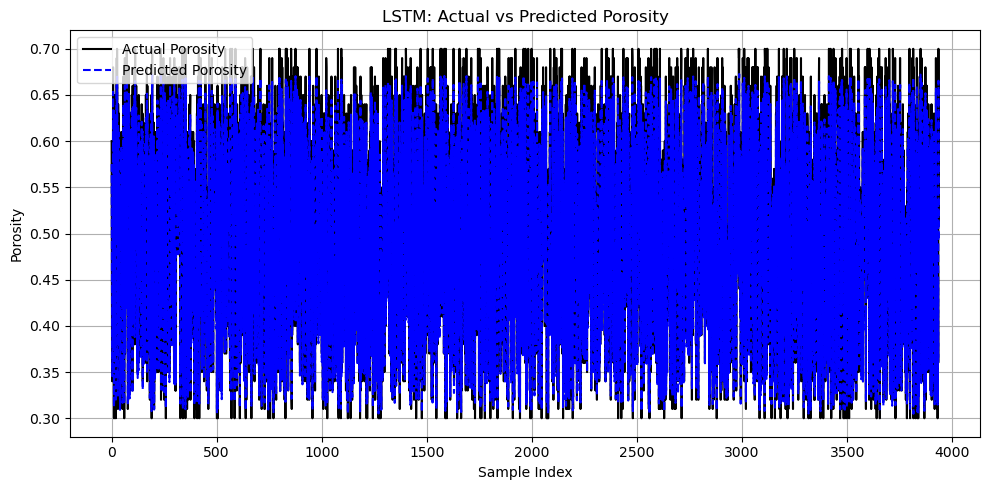

y_true[:5]: [0.6  0.49 0.35 0.34 0.37]
y_pred[:5]: [0.5751903  0.48253337 0.35330066 0.34552488 0.36776012]


In [21]:

y_pred_scaled = model_lstm.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("LSTM: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


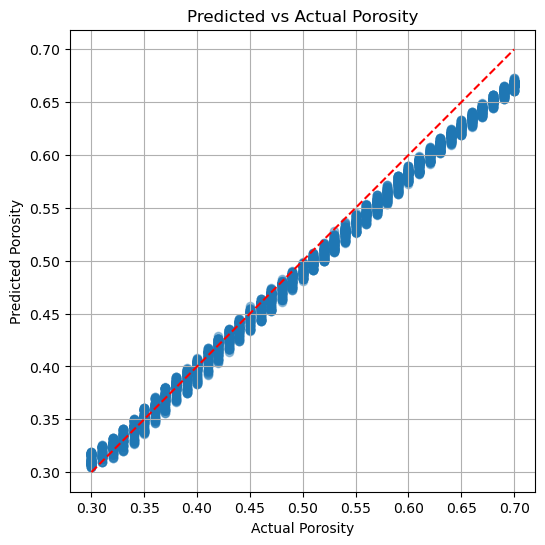

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()


In [23]:
from tensorflow.keras.layers import GRU


# Build GRU model
model_gru = Sequential([
    GRU(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_gru.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0162 - mae: 0.0870 - val_loss: 0.0018 - val_mae: 0.0351
Epoch 2/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0023 - mae: 0.0376 - val_loss: 0.0010 - val_mae: 0.0258
Epoch 3/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0013 - mae: 0.0283 - val_loss: 6.5432e-04 - val_mae: 0.0199
Epoch 4/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0011 - mae: 0.0253 - val_loss: 0.0028 - val_mae: 0.0462
Epoch 5/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7.9495e-04 - mae: 0.0219 - val_loss: 0.0020 - val_mae: 0.0351
Epoch 6/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.0294e-04 - mae: 0.0207 - val_loss: 0.0020 - val_mae: 0.0383
Epoch 7/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.3437e-04 - mae: 0.0197 - val_loss: 0.0029 - val_mae: 0.0420
Epoch 8/100
492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.1243e-04 - mae: 0.0178 - val_loss: 0.0022 - val_mae: 0.0358
Epoch 9/100
492/492 ━━━━━━━━

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE: 0.0102
MAE:  0.0080
R²:   0.9924


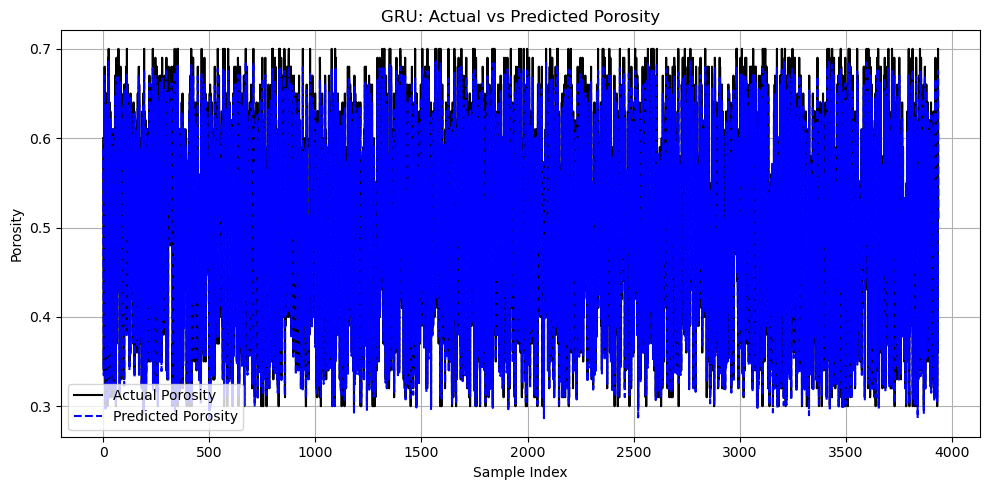

y_true[:5]: [0.6  0.49 0.35 0.34 0.37]
y_pred[:5]: [0.587292   0.4949161  0.3555835  0.33447242 0.3672897 ]


In [24]:

y_pred_scaled = model_gru.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("GRU: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


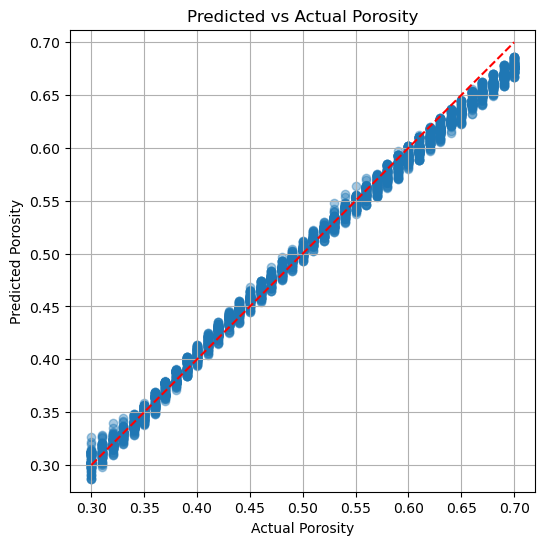

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()


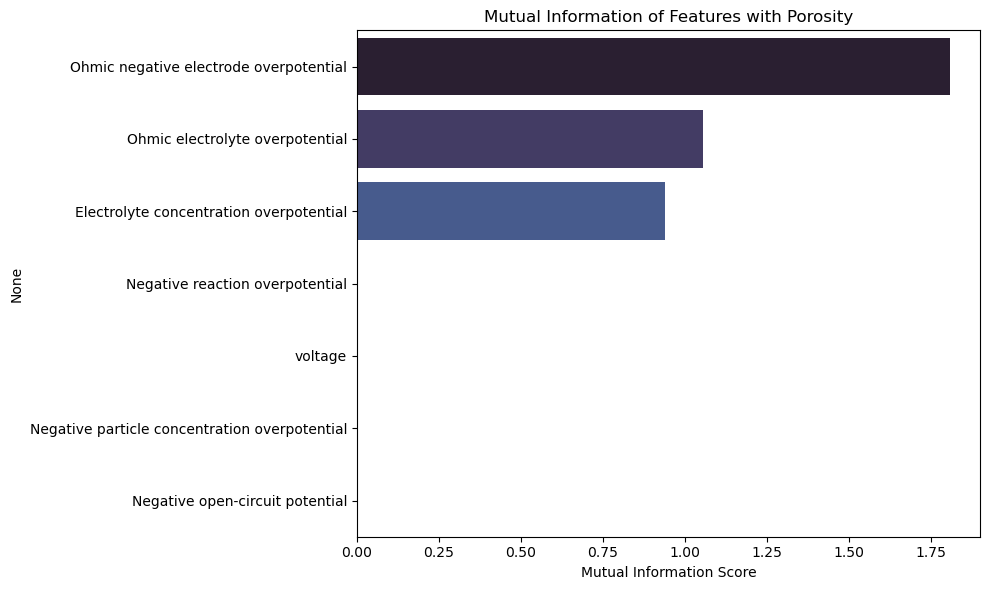

In [35]:
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression



X = df[feature_cols]
y = df["porosity"]

mi_scores = mutual_info_regression(X, y, random_state=42)

# Create a Series for plotting
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="mako")
plt.title("Mutual Information of Features with Porosity")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()


In [43]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R²:   {r2:.4f}")


Random Forest RMSE: 0.0009
Random Forest R²:   0.9999


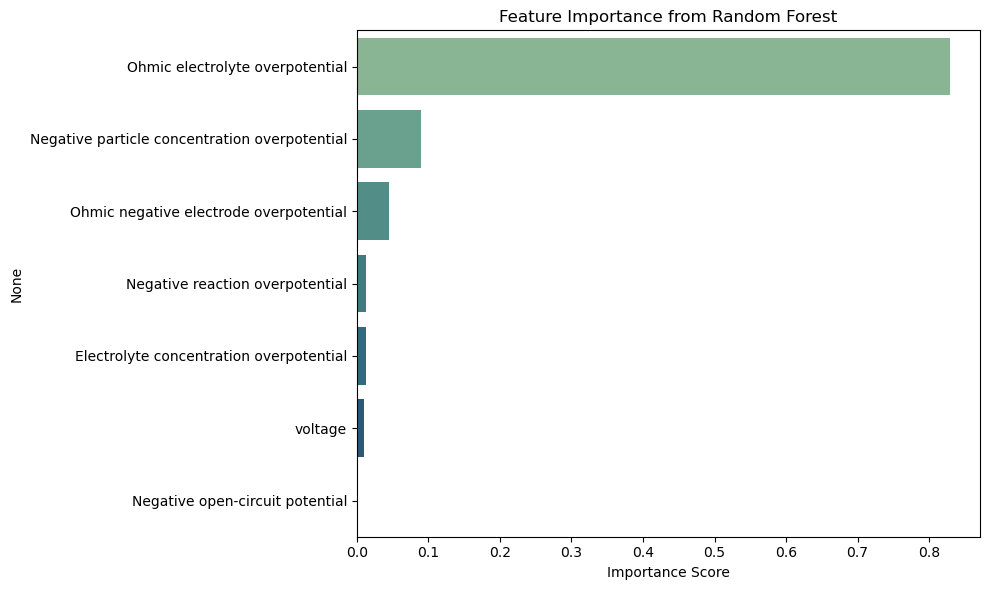

In [45]:
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="crest")
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
